In [1]:
#Purpose
#analysing rising sea level trends in the Pacific and assessing the projected impact on low-lying nations

#Step 0 Importing Libraries
library(tidyverse)
library(ggplot2)
library(reshape2)

Warning message:
"package 'ggplot2' was built under R version 4.5.3"
── Attaching core tidyverse packages ─────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ───────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'reshape2' was built under R version 4.5.3"

Attaching package: 'reshape2'


The following object is masked from 'package:tidyr':

    smiths




In [2]:
#Step 0 Importing dataset and inspection
main_df <- read.csv("USStationsLinearSeaLevelTrends.csv")

In [3]:
glimpse(main_df) #Transposed view of entire dataset, running horizontal instead of vertical

Rows: 149
Columns: 12
$ Station.ID               <int> 1611400, 1612340, 1612480, 1615680, 1617433, …
$ Station.Name             <chr> "Nawiliwili, HI", "Honolulu, HI", "Mokuoloe, …
$ First.Year               <int> 1955, 1905, 1957, 1947, 1988, 1927, 1947, 199…
$ Last.Year                <int> 2025, 2025, 2025, 2025, 2025, 2025, 2025, 202…
$ Year.Range               <int> 71, 121, 69, 79, 38, 99, 79, 33, 17, 80, 76, …
$ X..Complete              <int> 100, 100, 84, 96, 92, 85, 96, 96, 95, 99, 94,…
$ MSL.Trends..mm.yr.       <dbl> 1.90, 1.57, 1.79, 2.30, 3.81, 3.15, 1.58, 5.3…
$ X....95..CI..mm.yr.      <dbl> 0.37, 0.19, 0.47, 0.36, 0.96, 0.27, 0.36, 2.8…
$ MSL.Trend..ft.century.   <dbl> 0.62, 0.51, 0.59, 0.75, 1.25, 1.03, 0.52, 1.7…
$ X....95..CI..ft.century. <dbl> 0.12, 0.06, 0.16, 0.12, 0.31, 0.09, 0.12, 0.9…
$ Latitude                 <dbl> 21.9544, 21.3033, 21.4331, 20.8949, 20.0366, …
$ Longitude                <dbl> -159.3561, -157.8645, -157.7900, -156.4690, -…


In [4]:
head(main_df) #irst 5 rows of the Relative Sea Level Trends for Honolulu, Hawaii

,Station.ID,Station.Name,First.Year,Last.Year,Year.Range,X..Complete,MSL.Trends..mm.yr.,X....95..CI..mm.yr.,MSL.Trend..ft.century.,X....95..CI..ft.century.,Latitude,Longitude
,<int>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1611400,"Nawiliwili, HI",1955,2025,71,100,1.90,0.37,0.62,0.12,21.9544,-159.3561
2,1612340,"Honolulu, HI",1905,2025,121,100,1.57,0.19,0.51,0.06,21.3033,-157.8645
3,1612480,"Mokuoloe, HI",1957,2025,69,84,1.79,0.47,0.59,0.16,21.4331,-157.7900
4,1615680,"Kahului, HI",1947,2025,79,96,2.30,0.36,0.75,0.12,20.8949,-156.4690
5,1617433,"Kawaihae, HI",1988,2025,38,92,3.81,0.96,1.25,0.31,20.0366,-155.8294
6,1617760,"Hilo, HI",1927,2025,99,85,3.15,0.27,1.03,0.09,19.7303,-155.0556


In [5]:
#The dataset I've used contains 149 US tide gauge stations
#Columns include: Station.ID, Station.Name, First.Year, Last.Year, Year.Range, X..Complete, 
#MSL.Trends..mm.yr., X....95..CI..mm.yr.
#MSL.Trend.ft.century.
#X....95..CI..ft.century.
#Latitude
#Longitude

In [6]:
#Step 1: Transforming into wide format
#Step 1.1 - Building the  Matrix

#Building a matrix using the four columns of MSL.Trends..mm.yr, Latitude, Longitude, Year.Range to answer the question:
#"Does the location of a station relate to how fast sea levels are rising?"
sea_matrix <- matrix(
    c(main_df$MSL.Trends..mm.yr.,
      main_df$Latitude,
      main_df$Longitude,
      main_df$Year.Range),
    nrow = 149,
    ncol = 4
    )

#Assigning station names as row labels
rownames(sea_matrix) <- main_df$Station.Name

# Assign variable names as column labels
colnames(sea_matrix) <- c("MSL_Trend_mm_yr", "Latitude", "Longitude", "Year_Range")

# Preview the first 6 stations 
head(sea_matrix)

,MSL_Trend_mm_yr,Latitude,Longitude,Year_Range
"Nawiliwili, HI",1.90,21.9544,-159.3561,71
"Honolulu, HI",1.57,21.3033,-157.8645,121
"Mokuoloe, HI",1.79,21.4331,-157.7900,69
"Kahului, HI",2.30,20.8949,-156.4690,79
"Kawaihae, HI",3.81,20.0366,-155.8294,38
"Hilo, HI",3.15,19.7303,-155.0556,99


In [7]:
#Step 1.2 Scaling the Matrix
#Scaling the matrix so all four variables are on the same scale and remove any possibility of extreme values e.g -149 or 1.90 for distorting correlation results.
scaled_matrix <- scale(sea_matrix)

#Preview first 6 sections
head(scaled_matrix) #The results now have the smaller numbers centred around 0 (standardisation)

,MSL_Trend_mm_yr,Latitude,Longitude,Year_Range
"Nawiliwili, HI",-0.15901170,-1.235587,-1.330438,-0.02419084
"Honolulu, HI",-0.23918608,-1.289875,-1.299197,1.81480691
"Mokuoloe, HI",-0.18573649,-1.279052,-1.297637,-0.09775075
"Kahului, HI",-0.06183064,-1.323927,-1.269970,0.27004880
"Kawaihae, HI",0.30502788,-1.395491,-1.256574,-1.23792936
"Hilo, HI",0.14467912,-1.421030,-1.240367,1.00564790


In [8]:
#Step 1.3 Correlating the Matrix
cor_matrix <- cor(scaled_matrix)

print(round(cor_matrix, 2)) #Rounded to 2 decimal places for better readability

                MSL_Trend_mm_yr Latitude Longitude Year_Range
MSL_Trend_mm_yr            1.00    -0.59      0.30      -0.12
Latitude                  -0.59     1.00     -0.40       0.03
Longitude                  0.30    -0.40      1.00       0.08
Year_Range                -0.12     0.03      0.08       1.00


In [9]:
#Does location relate to sea level rise rate?

## MSL_Trend_mm_yr vs Latitude (-0.59 strong negative relationship):
# Stations further NORTH tend to have LOWER or negative sea level rise rates.
# This makes sense — Alaska's stations are far north and show falling sea levels
# due to land rising faster than the sea due to ice melting (Peltier, 2004, p. 111)

# MSL_Trend_mm_yr vs Longitude (0.30 weak positive relationship):
# Stations further EAST tend to have slightly HIGHER sea level rise rates.
# This reflects that eastern US stations (TX, LA, VA) show higher rates
# than western stations (CA, OR, WA).

# MSL_Trend_mm_yr vs Year_Range (-0.12 very weak negative relationship):
# Almost no relationship between record length and sea level rise rate.
# This is actually reassuring — it suggests our trends are not simply
# an artefact of how long a station has been recording.

# Latitude vs Longitude (-0.40 moderate negative relationship):
# Simply reflects the geographic shape of the US coastline —
# northern stations tend to be on the western coast.

In [10]:
#Step 1.4 Reshaping the correlated matrix back into long form 
melted <- melt(cor_matrix) #Creates one row per variable pair, which is necessary for geom_tile()

head(melted) #Preview melted data

,Var1,Var2,value
,<fct>,<fct>,<dbl>
1,MSL_Trend_mm_yr,MSL_Trend_mm_yr,1.0000000
2,Latitude,MSL_Trend_mm_yr,-0.5949841
3,Longitude,MSL_Trend_mm_yr,0.2952592
4,Year_Range,MSL_Trend_mm_yr,-0.1151866
5,MSL_Trend_mm_yr,Latitude,-0.5949841
6,Latitude,Latitude,1.0000000


[1] "Heatmap saved"


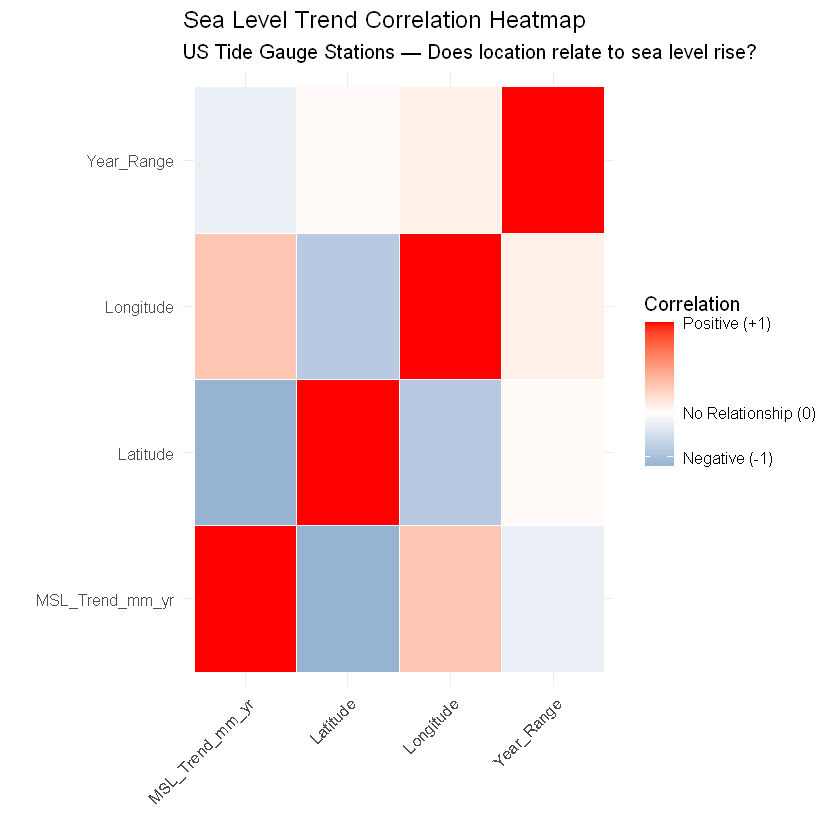

In [42]:
#Step 1.5 Creating the Heatmap with geom_tile()
#Using ggplot2, the melted cor_matrix is going to be visualised as a heatmap.

ggplot(melted, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile(color = "white", linewidth = 0.5) +
  scale_fill_gradient2(
    low      = "steelblue", #negative correlation 
    high     = "red", #positive correlation
    mid      = "white", #no correlation
    midpoint = 0,
    breaks   = c(-0.5, 0, 1), # position of legend labels. Note: -0.5 was chosen since the lowest value was -0.59 and the only way for Negative -1 to appear was to make column value -0.5
    labels   = c("Negative (-1)", "No Relationship (0)", "Positive (+1)"), # legend text
    name     = "Correlation"
  ) +
  theme_minimal(base_size = 12) + #keeps the design clean and readable
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(
    title    = "Sea Level Trend Correlation Heatmap",
    subtitle = "US Tide Gauge Stations — Does location relate to sea level rise?",
    x        = "",
    y        = ""
  )

ggsave("Sea_Level_Trend_Correlation_Heatmap.png", width = 7, height = 5) #Exporting heatmap into a png format
print("Heatmap saved") 

In [ ]:
#MSL_Trend_mm_yr vs Latitude — Dark steelblue (-0.59)
#Strongest negative correlation relationship

#MSL_Trend_mm_yr vs Longitude - Light red, (+0.30)
#Weakest positive correlation relationship 

#MSL_Trend_mm_yr vs Year_Range - Light grey/blue (-0.12) 
#Most negligible finding in correlation relationship.

#Correlation does not imply causation (SAE-AU, 2025, p. 125).
#    Latitude being correlated with MSL trend does not mean latitude
#    directly causes sea level change — other factors such as land
#    subsidence, ocean currents, and glacial rebound are the true drivers.